In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import os
import glob
import shutil

import xarray as xr
import numpy as np
from pyhomogenize import open_xrdataset
import seaborn as sns

from cmcrameri import cm
from cdo import *
cdo = Cdo()   #(tempdir="")
cdo.forceOutput = True
forceCDO = True

In [3]:
import dask
from dask.distributed import Client

In [4]:
def remap(RCM, datadir, tmpdir, infile, griddir, grid):

    if RCM == 'ICTP':
        gridr=griddir+'/grid_ICTP-RegCM4-6.txt'
        print('ICTP-remap')
    elif RCM == 'CNRM':
        print('CNRM-remap')
        gridr=griddir+'/grid_CNRM-ALADIN63.txt'
    else:
        print('grid not found')
    
    outfile=os.path.join(datadir,infile)
    file=os.path.join(tmpdir,infile)
    
    print('grid used: ', gridr)
    
    f1=cdo.setgrid(gridr,input=file)
    cdo.remapcon(grid,input=f1, output=outfile)

In [5]:
def setgrid(datadir, tmpdir, infile, grid):
    outfile=os.path.join(datadir,infile)
    file=os.path.join(tmpdir,infile)
    cdo.setgrid(grid,input=file, output=outfile)
    return

In [6]:
import scipy.stats as sts
import xarray as xr
import dask
from pyhomogenize import open_xrdataset, save_xrdataset

In [7]:
def calculate_pvalue(ds, ds_ref, var):
    print("Do Mann-Whitney-U-Test.")
    ds_ref = ds_ref.chunk(dict(time=-1))
    ds = ds.chunk(dict(time=-1))
    
    def _mannwhitneyu(sample1, sample2):
        return sts.mannwhitneyu(
            sample1, 
            sample2, 
            nan_policy = "omit",
        )[1]
    da = xr.apply_ufunc(
        _mannwhitneyu,
        ds_ref[var],
        ds[var],
        input_core_dims=[["time"], ["time"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes = ["float32"],
        keep_attrs = True,
    ).compute()
    ds["p_value"] = da
    ds["significance"] = xr.where(da < 0.05, 1, 0)
    ds["significance"].attrs = ds["p_value"].attrs
    return ds


In [8]:
def seltimeslice(sim,outfilename,outdatadir):
    '''
    Select timeslice, output annual files (30 timesteps)
    calculate mean over timeslice 
    calculate difference
    calculate significance of change
    '''
    
    for timeslice in ('1972/2001','2070/2099', '2022/2051'):
        timeslicen=timeslice.replace('/','_')
        outfile=os.path.join(outdatadir,timeslicen+'_'+outfilename)
        print('sel time slice : ',sim)
        cdo.selyear(timeslice, input=sim, output=outfile)
        
        outfilemean=os.path.join(outdatadir,'MEAN_'+timeslicen+'_'+outfilename)
        cdo.timmean(input=outfile, output=outfilemean)
        
        print(outfile)
        print('calculate significance')
        
        if timeslice != '1972/2001':
            ds = xr.open_mfdataset(outfile, decode_times=False)
            ds_ref_c = ds_ref.copy()
            ds = ds.fillna(0)
            print('len(ds.time): ',len(ds.time))
            print('len(ds_ref_c.time): ',len(ds_ref_c.time))
            if len(ds.time) < len(ds_ref_c.time):
                ds_ref_c = ds_ref_c.isel(time=slice(0,len(ds.time)))
                print('len(ds_ref_c.time): ',len(ds_ref_c.time))
            ds_ref_c["time"] = ds.time
            ds_ref_c = ds_ref_c.fillna(0)
            outfilesig=os.path.join(outdatadir,'significance_'+timeslicen+'_'+outfilename)

            ds_p = calculate_pvalue(ds, ds_ref_c, "sd")           
            print('outfilemean: ',outfilemean)
            ds_mean = xr.open_mfdataset(outfilemean, decode_times=False)
            del ds_mean["time"]
            if "time_bnds" in ds_mean.data_vars:
                del ds_mean["time_bnds"]
            ds_mean = ds_mean.squeeze()
            ds_p["sd_diff"] = ds_mean["sd"] - ds_hist_mean["sd"]
            save_xrdataset(ds_p, outfilesig)
            print("File written: ", outfilesig)
        
        else:
            print('read historical')
            ds_ref = xr.open_mfdataset(outfile, decode_times=False)
            ds_hist_mean = xr.open_mfdataset(outfilemean, decode_times=False) 
            del ds_hist_mean["time"]
            if "time_bnds" in ds_hist_mean.data_vars:
                del ds_hist_mean["time_bnds"]
            ds_hist_mean = ds_hist_mean.squeeze()
    return

In [9]:
def calculate_ensemble_robustness(
        da_diff,
        da_sig,
        ensemble_dim,
        compute=True,
):
    def _where(
            da,
            rel_op,
            rel_value=0,
            then_value=1,
            else_value=0,
    ):
        if rel_op == ">":
            return xr.where(da > rel_value, then_value, else_value)
        if rel_op == "<":
            return xr.where(da < rel_value, then_value, else_value)
        if rel_op == "==":
            return xr.where(da == rel_value, then_value, else_value)
        raise("relational operator {} not known.").format(rel_op)

    def _percentage(da, da_ref, dim):
        da_s = da.sum(dim=dim)
        da_c = da_ref.count(dim=dim)
        return xr.where(da_c > 0, da_s / da_c, np.nan)
    
    diff_p = _where(da_diff, ">")
    diff_n = _where(da_diff, "<")
    #diff_0 = _where(ds[diff], "==")
    diff_p_p = _percentage(diff_p, da_diff, ensemble_dim)
    diff_n_p = _percentage(diff_n, da_diff, ensemble_dim)
    #diff_0_p = _percentage(diff_0, ds[diff], ensemble_dim)

    sig_p = _where(diff_p, "==", rel_value=1, then_value=da_sig)
    sig_n = _where(diff_n, "==", rel_value=1, then_value=da_sig)
    #sig_0 = _where(diff_0, "==", rel_value=1, then_value=ds[sig])
    sig_p_p = _percentage(sig_p, da_diff, ensemble_dim)
    sig_n_p = _percentage(sig_n, da_diff, ensemble_dim)
    #sig_0_p = _percentage(sig_0, ds[diff], ensemble_dim)

    da = xr.where(((diff_p_p >= 2/3) & (sig_p_p >= 1/2)), 1, 0)
    da = xr.where(((diff_n_p >= 2/3) & (sig_n_p >= 1/2)), -1, da)
    if compute is True:
        da = da.compute()
    return da

In [10]:
def ensemblemean_exp(outdatadir):
    ''' calculate mean for each scenario'''
    for timeslice in ['1972_2001', '2022_2051', '2070_2099']:
        for exp in ['rcp26','rcp45','rcp85']:
            outputfile=os.path.join(outdatadir,'ENS_MEAN_'+timeslice+'_'+exp+'.nc')
            ensemble_mean_files = glob.glob(outdatadir+'MEAN_'+timeslice+'*'+exp+'*.nc')
            #ensemble_mean_files = [ 
            #    outdatadir+'MEAN_'+timeslice+'_NCC-NorESM1-M_'+exp+'_r1i1p1_GERICS-REMO2015.nc', 
            #    outdatadir+'MEAN_'+timeslice+'_MOHC-HadGEM2-ES_'+exp+'_r1i1p1_CLMcom-ETH-COSMO-crCLIM-v1-1.nc',
            #]
            cdo.ensmean(input=ensemble_mean_files, output=outputfile)
            print('Ensemble mean is calculated:', outputfile)
            if timeslice != "1972_2001":
                
                ensemble_sig_files = glob.glob(outdatadir+'significance_'+timeslice+'*'+exp+'*.nc')
                                
                #ensemble_sig_files = [ 
                #    outdatadir+'significance_'+timeslice+'_NCC-NorESM1-M_'+exp+'_r1i1p1_GERICS-REMO2015.nc', 
                #    outdatadir+'significance_'+timeslice+'_MOHC-HadGEM2-ES_'+exp+'_r1i1p1_CLMcom-ETH-COSMO-crCLIM-v1-1.nc',
                #]
                                               
                datasets = []
                for ifile in ensemble_sig_files:
                    ds = xr.open_mfdataset(ifile, decode_times=False) 
                    print('ifile =', ifile)
                    #
                    filename=ifile.split('/')[9]
                    #significance_2022_2051_MPI-M-MPI-ESM-LR_rcp85_r3i1p1_CLMcom-ETH-COSMO-crCLIM-v1.1.nc'
                    tmp=filename.split('_')[6]
                    RCM=tmp.split('.')[0]
                    #print(RCM)
                    if RCM == "CLMcom-ETH-COSMO-crCLIM-v1":
                        print(RCM)
                        ds.attrs["driving_model_id"] = "MPI-ESM-LR"
                        ds.attrs["model_id"] = "CLMcom-ETH-COSMO-crCLIM-v1.1"
                        
                    gcm = ds.attrs["driving_model_id"]
                    rcm = ds.attrs["model_id"]
                    gcmrcm = "{}-{}".format(gcm, rcm)
                    ds = ds.assign_coords({"GCM-RCM": gcmrcm})
                    del ds["sd"]
                    del ds["p_value"]
                    del ds["time"]
                    if "time_bnds" in ds.data_vars:
                        del ds["time_bnds"]
                    ds["significance"] = ds["significance"].expand_dims("GCM-RCM")
                    ds["sd_diff"] = ds["sd_diff"].expand_dims("GCM-RCM")
                    datasets += [ds]
                ds_total = xr.concat(datasets, dim="GCM-RCM", data_vars=["sd_diff", "significance"], compat="override", coords="minimal")
                ds_total["robustness"] = calculate_ensemble_robustness(
                    da_diff=ds_total["sd_diff"],
                    da_sig=ds_total["significance"],
                    ensemble_dim="GCM-RCM",
                )
                ds_total["sd_ensemble_diff"] = ds_total["sd_diff"].mean(dim="GCM-RCM")
                outputfile=os.path.join(outdatadir,'ENS_ROBUSTNESS_'+timeslice+'_'+exp+'.nc')
                ds_total.to_netcdf(outputfile)
                print('Ensemble robustness is calculated:', outputfile)
            
    return


In [11]:
def directory_available(dir):
    if not os.path.exists(dir):
        os.makedirs(dir)
    return

Data is available here:
https://swiftbrowser.dkrz.de/tcl_objects/2024-04-24T18:59:16Z/r_a7bd2797978dbb6861d3ffdc1d71967a63b9269e/w_/dkrz_ffd3ca9004324ad28243244b834f92b1/EUR11_SNOWDAY_YEAR/0/

copy into tmpdir , see below

In [12]:
home=os.getcwd()
home

'/home/g/g300047/SCRIPTS/github/snow-research/plotting-py/HORIZONTAL'

In [13]:
# set your own home here and plot dir

datadir=home+'/SNOWDAY-YEAR/'
outdatadir=home+'/SNOWDAY-timeslice/'
tmpdir=home+'/tmp/'
plotdir=home+'/plots/HORIZONTAL/'

files are not always replace it seems, better delete outdatadir before running

In [14]:
directory_available(outdatadir)
directory_available(plotdir)

Grid:

In [15]:
print('home: ',home)
griddir=home.replace('plotting-py/HORIZONTAL','grid')
grid=home.replace('plotting-py/HORIZONTAL','grid/EUR11-grid.txt')
griddir


home:  /home/g/g300047/SCRIPTS/github/snow-research/plotting-py/HORIZONTAL


'/home/g/g300047/SCRIPTS/github/snow-research/grid'

In [16]:
sims = glob.glob(tmpdir+'*.nc')

## Regridding
CNRM, ICTP, MPI-CSC:
Three regional climate simulation have not been provide on the regular EURO-CORDEX $0.11^\circ $ grid and had to be remapped. ALADIN63 and RegCM4-6 are remapped by using the CDO remapping method \textit{remapcon}. MPI-CSC-REMO2009 is on a shiftet EURO-CORDEX grid and is moved with \textit{cdo set grid} to the standard EURO-CORDEX $ 0.11^\circ $ grid.

In [17]:
grid

'/home/g/g300047/SCRIPTS/github/snow-research/grid/EUR11-grid.txt'

In [17]:
sims_remaped=glob.glob(datadir+'*.nc')
#sims_remaped

Only run the next routine once, it takes a long time 

In [18]:
grid

'/home/g/g300047/SCRIPTS/github/snow-research/grid/EUR11-grid.txt'

### Colors for absolut snw

In [50]:
#snw-absolut
#level_steps=[1,15,30,45,60,75,90,105,120,135,150,165,180,195,210]
level_steps=[1,30,60,90,120,150,180,210,240,360]

#level_steps=[0,20,40,60,80,100,120,140,160,180,200,220] # Christian
#newcolors = cm.batlow_r(np.linspace(0,1,14))
#newcolors = cm.batlowW_r(np.linspace(0,1,11)) # Christian
#newcolors = cm.davos_r(np.linspace(0,1,14))
#newcolors = cm.imola_r(np.linspace(0,1,14))

#newcolors = sns.color_palette('mako_r')
#newcolors = sns.color_palette('viridis_r',14)
#newcolors = sns.color_palette('YlGnBu',13)
newcolors = ['#f0f0f0','#edf8b1','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#253494','#081d58','#3f007d','#e7298a']

### Colors for diff snw

In [29]:
#snw-diff
level_steps_diff=[-120,-90,-75,-60,-45,-30,-15,0,15]
newcolors = ['#3f007d','#081d58','#253494','#225ea8','#1d91c0','#41b6c4','#7fcdbb','#c7e9b4','#edf8b1','#f0f0f0']
    

In [51]:
from matplotlib.colors import ListedColormap
color_steps = ListedColormap(newcolors)
color_steps.set_bad(color="lightgrey")
color_steps.set_under(color="white")


In [57]:
import matplotlib
font = {
    'family' : 'sans-serif',
    'weight' : 'normal',
    'size'   : 15,
}

matplotlib.rc('font', **font)

def plot_3(
    ds_dict,
    var="",
    robustness=None,
    ts="",
    exp="",
    mode="absolut",
    add_cbar = True,
    hatchcolor="k",
    extend="neither",
):
    if mode == "absolut":
        levels=level_steps
        colors=color_steps
        vmin=0.00001
    elif mode == "diff":
        levels=level_steps_diff
        colors=color_steps
        vmin=-200 # macht keinen sinn
    else:
        print("Mode {} not known! Use 'absolut' or 'diff'")
        return

    import matplotlib.pyplot as plt
    import cordex
    import numpy as np
    from cartopy import crs as ccrs
    import cartopy.feature as cf
    
    cordex_grid = cordex.cordex_domain("EUR-11")
    rotated_lat_lon = cordex_grid.rotated_latitude_longitude
    pole = (rotated_lat_lon.grid_north_pole_longitude, rotated_lat_lon.grid_north_pole_latitude)
    projection = ccrs.RotatedPole(*pole)
    
    fig, (ax1, ax2, ax3) = plt.subplots(
        ncols=3, nrows=1, subplot_kw={"projection": projection}, figsize=(20, 8),
    )
    axes = (ax1, ax2, ax3)
    pos = .05
    for ax in axes:
        ax.gridlines(
            draw_labels={"bottom": "x", "left": "y"}, 
            dms=True,
            x_inline=False, 
            y_inline=False,
            linewidth=0.5,
        )
        ax.coastlines(resolution="50m", color="black", linewidth=1)
        ax.add_feature(cf.BORDERS)
        ax.set_extent([-22,10,-16,21])
        
    for expts, ax in zip(ds_dict, axes):
        im = ds_dict[expts][var].plot(
            ax=ax,
            levels=levels,
            colors=colors,
            transform=projection,
            extend=extend,
            add_colorbar=False,
            vmin=vmin,
            alpha=.8,  # bei diff
        )
        if robustness is True:
            rob_sel = ds_dict[expts]["robustness"]
            plt.rcParams.update({'hatch.color': hatchcolor})
            rob_sel = rob_sel.squeeze()
            significant = xr.where(rob_sel != 0, 1, 0).squeeze()
            significant.plot.contourf(
                ax=ax,
                levels=[-.5,.5],
                colors='none',
                hatches=[None, None, "//", "//"],
                add_colorbar=False,
                extend='both',
                transform=projection,
            )
        exp = expts.split("_")[0]
        ts = expts.split("_")[1]
        s = "Ensemble mean snow cover duration \n Annual ({}), {}".format(exp, ts)
        #s = "Mean change snow cover duration \n Annual ({}), {}".format(exp, ts)
        
        ax.set_title(s+": ", fontdict={"fontsize": 15})
    if add_cbar is True:
        cbar_ax = fig.add_axes([0.15, pos, 0.7, 0.03])
        fig.colorbar(im, cax=cbar_ax, orientation="horizontal", label='[ days / year ]')
    #savefig(plt, "{}/ensemble_mean_diff_snowcoverduration_{}_YlGrBl.png".format(output_path, ts))    
    savefig(plt, "{}/ensemble_mean_snowcoverduration_{}.png".format(output_path, ts))
    return plt

In [53]:
def savefig(plot, name):
    plot.savefig(name, dpi=300)

In [54]:
output_path = "/work/ch0636/g300047/SNOW-RESEARCH/plots/HORIZONTAL"

In [55]:
directory_available(output_path)

2021-2050
2069-2098


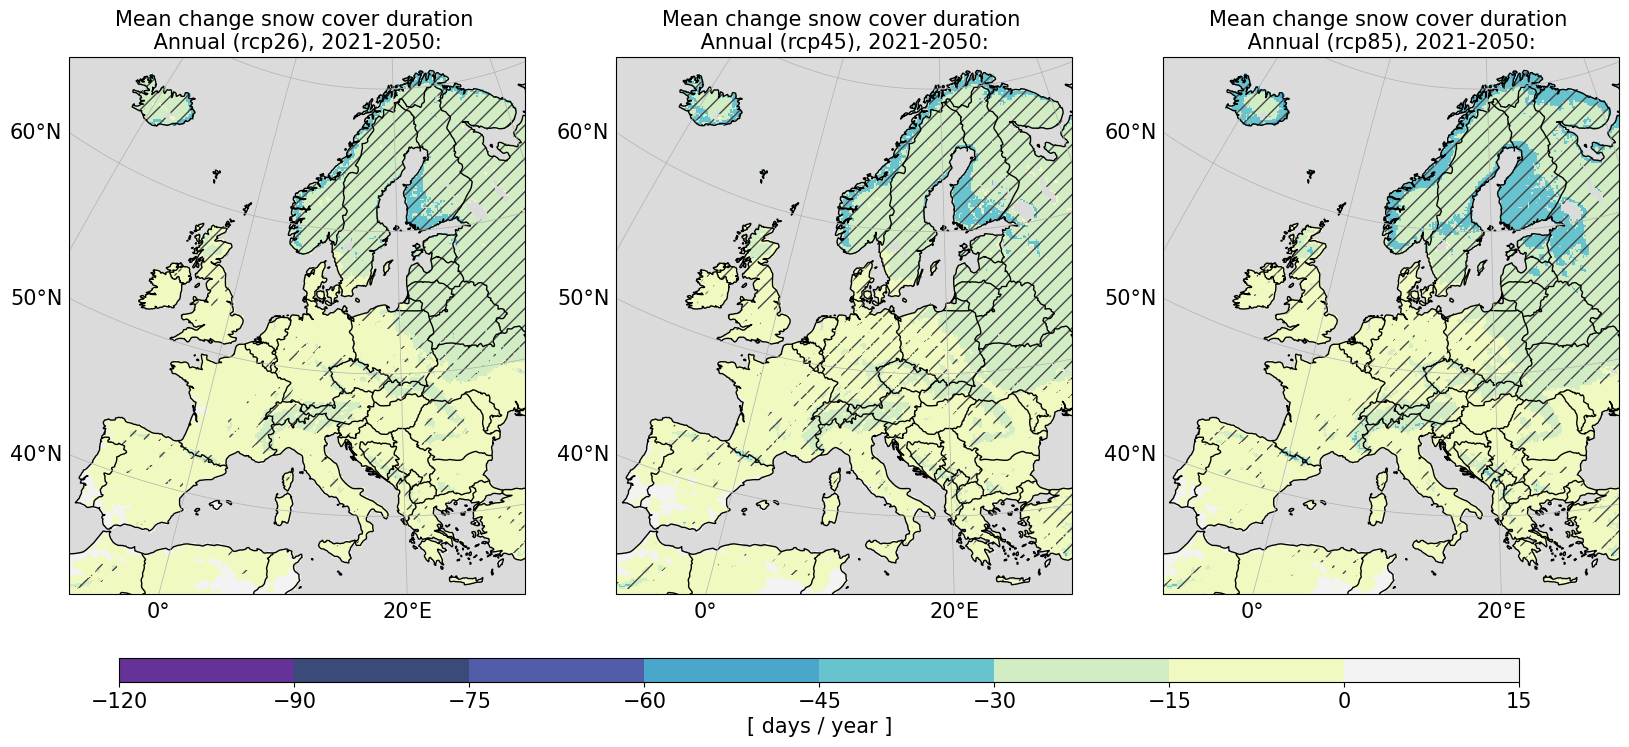

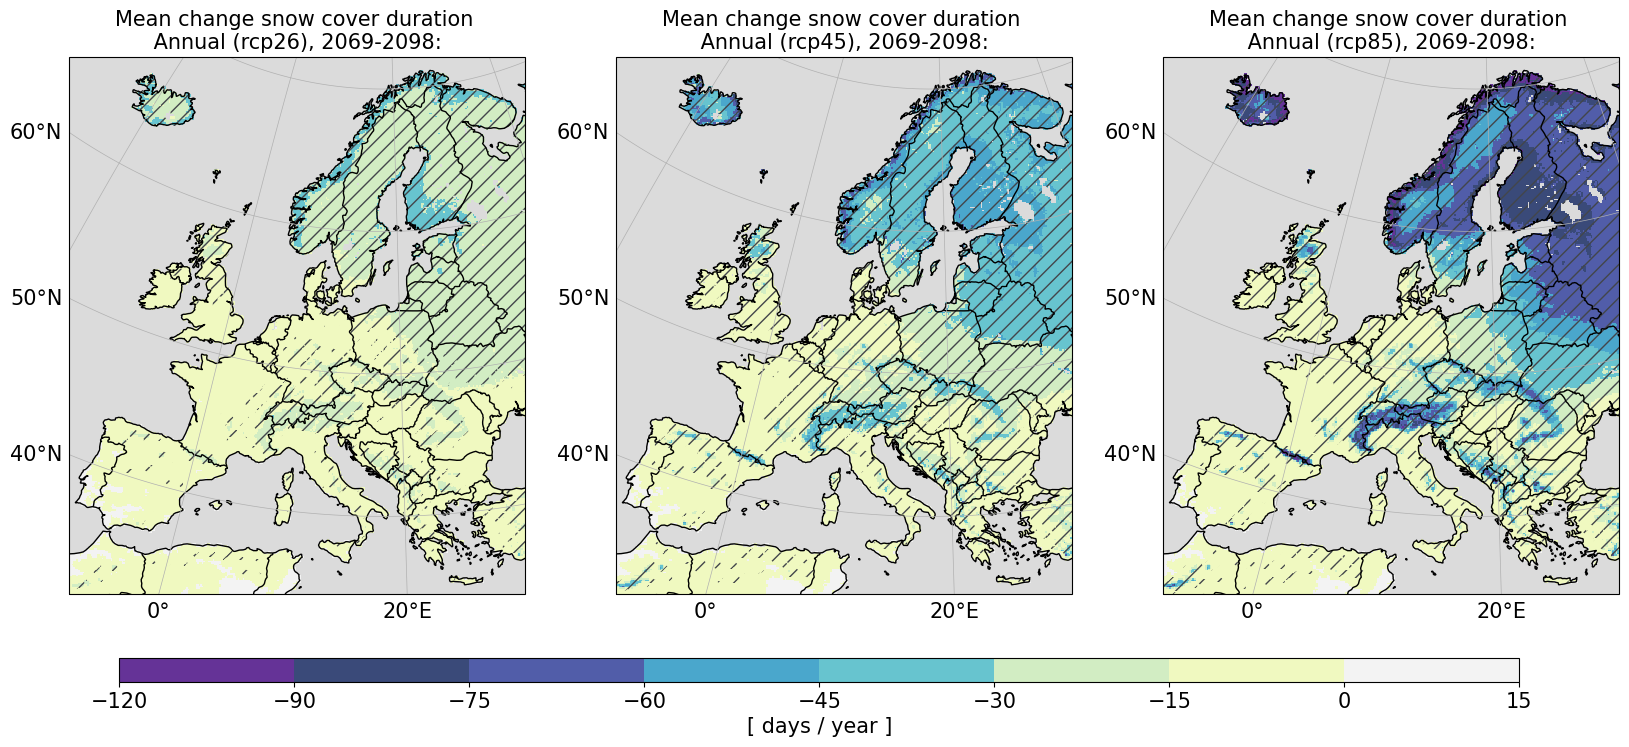

In [45]:
#plot3 for diff:

for timeslice in ('2022_2051', '2070_2099'):
    file1='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_ROBUSTNESS_'+timeslice+'_rcp26.nc'
    file2='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_ROBUSTNESS_'+timeslice+'_rcp45.nc'
    file3='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_ROBUSTNESS_'+timeslice+'_rcp85.nc'
    ds1 = xr.open_mfdataset(file1, decode_times=False)
    ds2 = xr.open_mfdataset(file2, decode_times=False)
    ds3 = xr.open_mfdataset(file3, decode_times=False)
    if timeslice == '2022_2051':
        time=timeslice.replace('2022_2051','2021-2050')
    else:
        time=timeslice.replace('2070_2099','2069-2098')
    print(time)
    ds_dict = {
    "rcp26_"+time: ds1,   
    "rcp45_"+time: ds2,    
    "rcp85_"+time: ds3,
        }
    #ds_dict
    plot_3(
        ds_dict,
        var="sd_ensemble_diff",
        mode="diff",
        robustness=True,
        # black hatchcolor="#020202"
        hatchcolor="#43464B"
    )

1971-2000
2021-2050
2069-2098


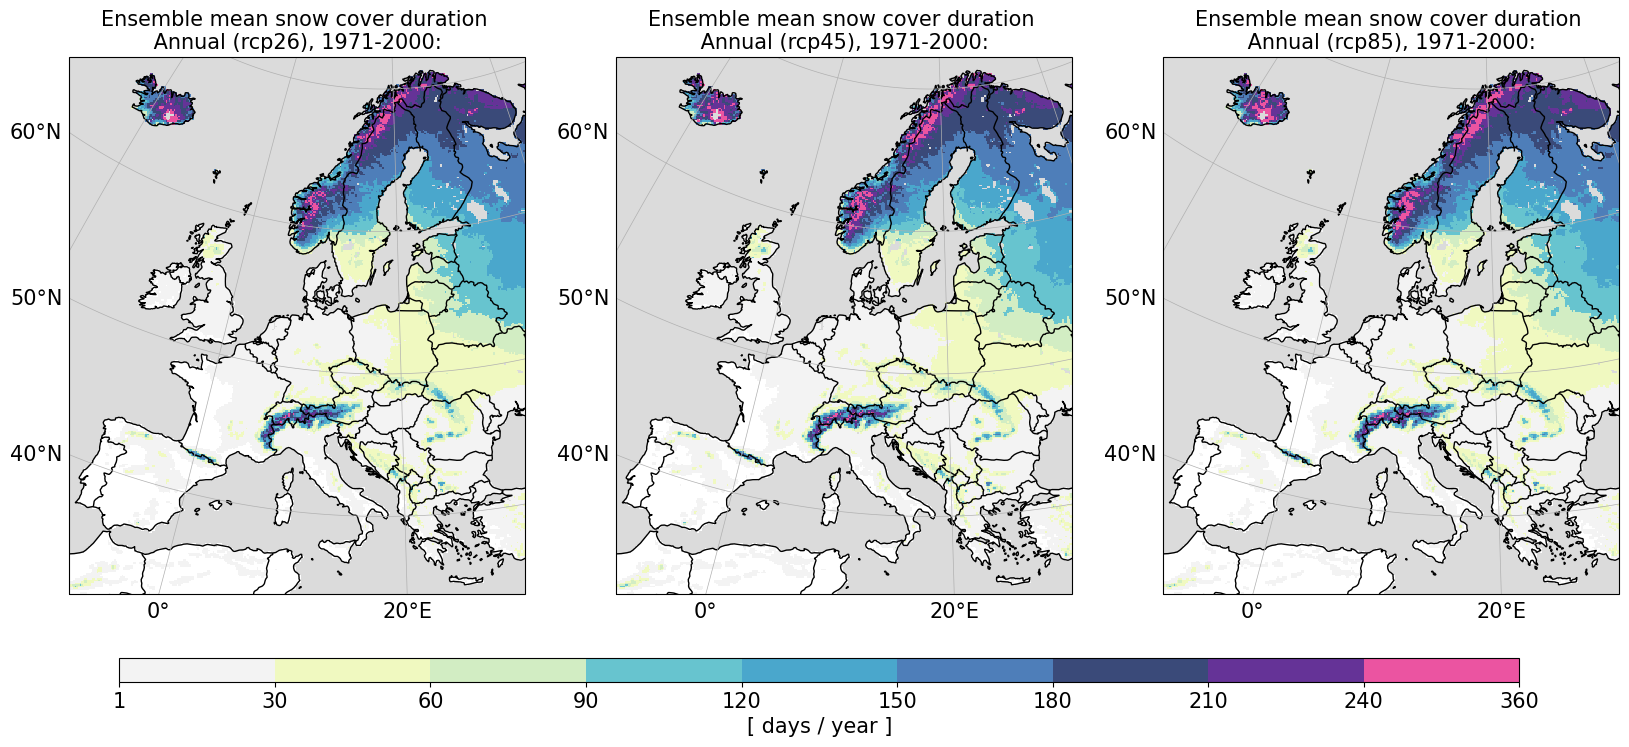

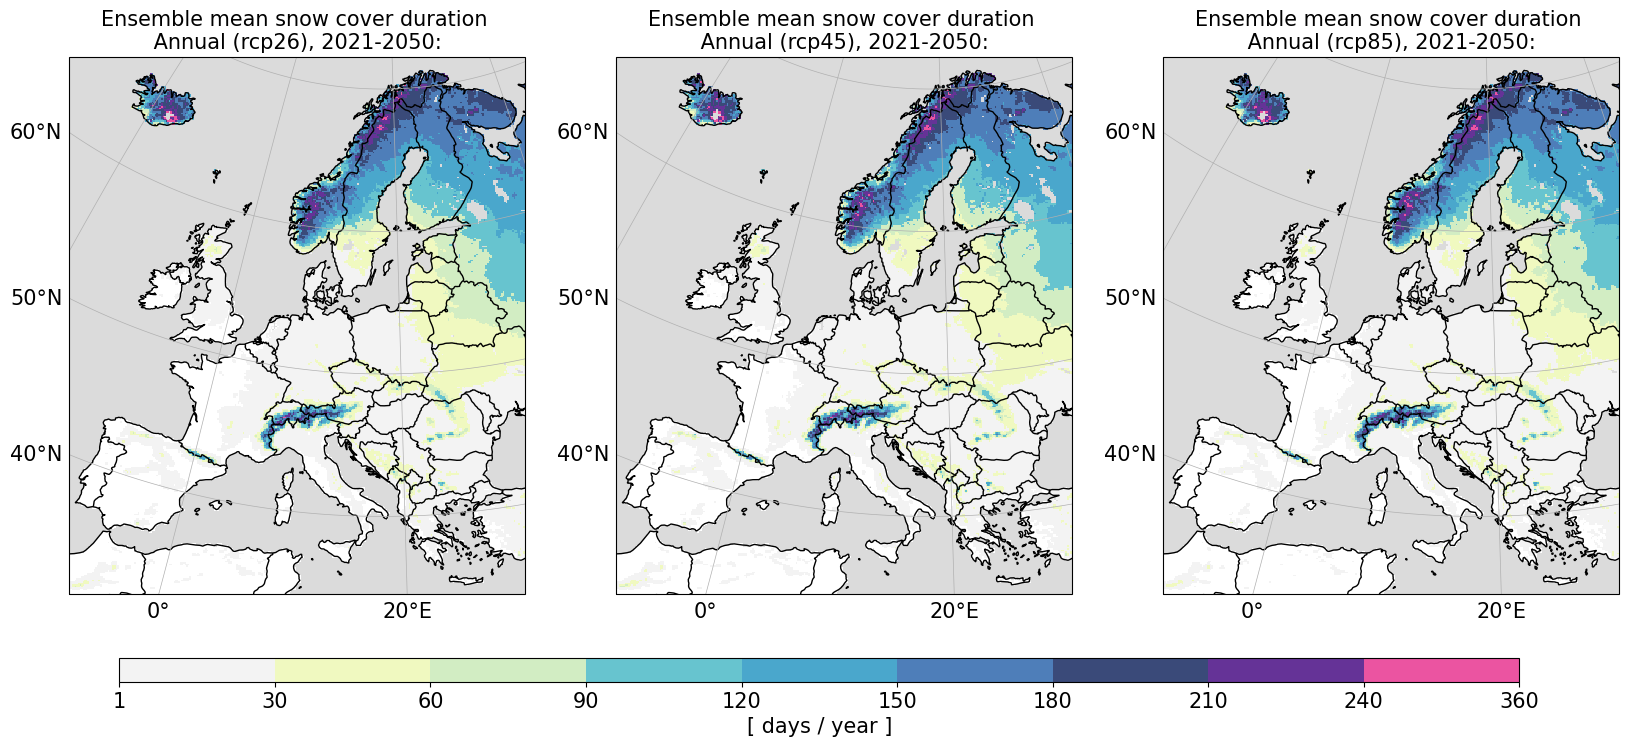

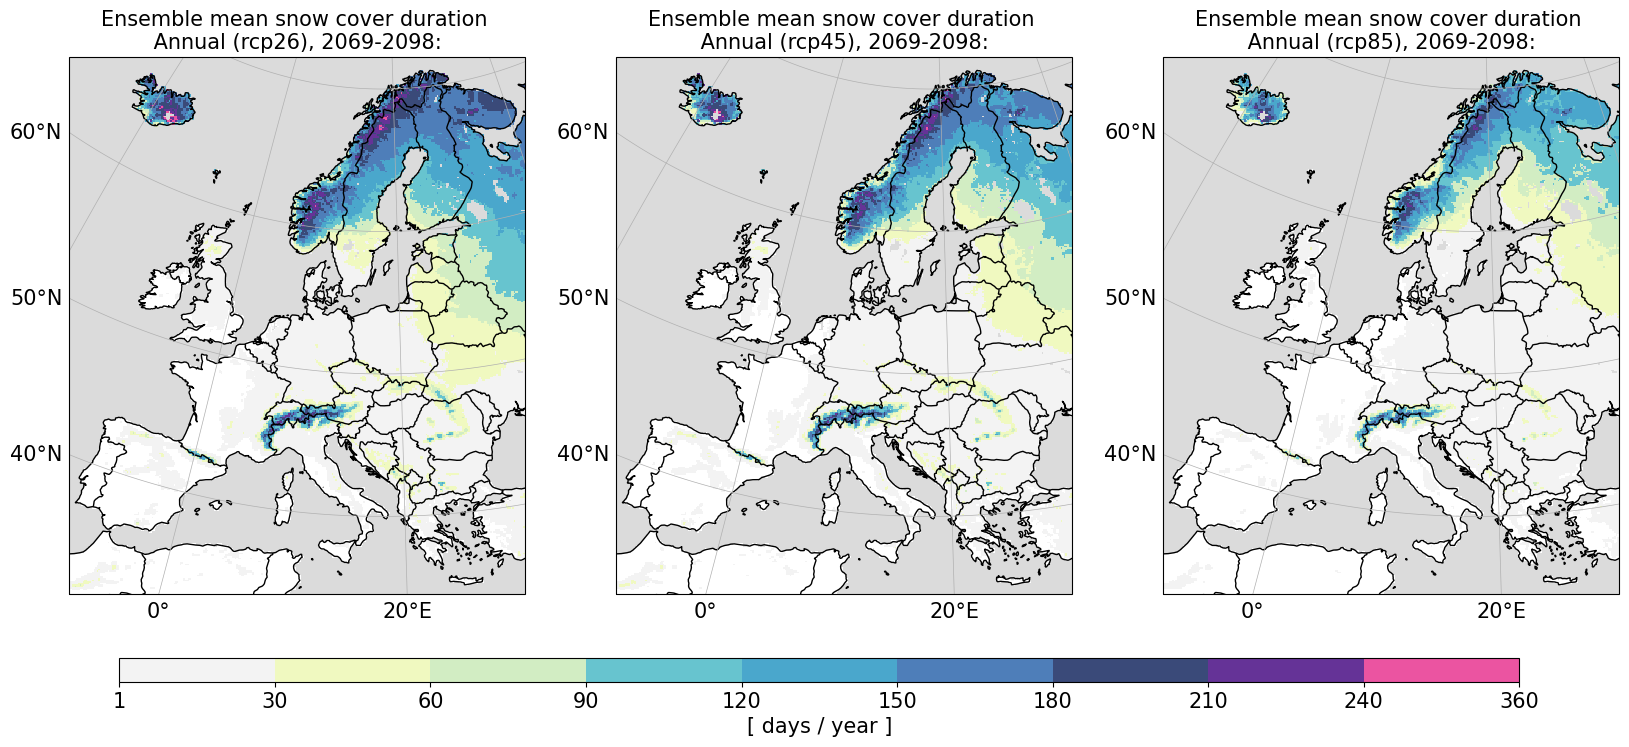

In [58]:
#plot 3 for absolut:

for timeslice in ('1972_2001', '2022_2051', '2070_2099'):
    file1='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_MEAN_'+timeslice+'_rcp26.nc'
    file2='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_MEAN_'+timeslice+'_rcp45.nc'
    file3='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_MEAN_'+timeslice+'_rcp85.nc'
    ds1 = xr.open_mfdataset(file1, decode_times=False)
    ds2 = xr.open_mfdataset(file2, decode_times=False)
    ds3 = xr.open_mfdataset(file3, decode_times=False)
    if timeslice == '1972_2001':
        time=timeslice.replace('1972_2001','1971-2000')
    elif timeslice == '2022_2051':
        time=timeslice.replace('2022_2051','2021-2050')
    else:
        time=timeslice.replace('2070_2099','2069-2098')
    print(time)
    ds_dict = {
    "rcp26_"+time: ds1,
    "rcp45_"+time: ds2,
    "rcp85_"+time: ds3,
        }
    #ds_dict
    plot_3(
    ds_dict,
    var="sd",
        )

In [59]:
import matplotlib
font = {
    'family' : 'sans-serif',
    'weight' : 'normal',
}

# haesslich:'monospace', 'serif'
# sehe den Unterschied nicht: 'fantasy','sans', 'sans serif', 'sans-serif'
matplotlib.rc('font', **font)

def plot_9(
    ds_dict,
    var="",
    robustness=None,
    ts="",
    exp="",
    mode="absolut",
    add_cbar = True,
    hatchcolor="k",
    extend="neither",
):
    if mode == "absolut":
        levels=level_steps
        colors=color_steps
    elif mode == "diff":
        levels=diff_category[var]
        colors=diff_colors[var]
    else:
        print("Mode {} not known! Use 'absolut' or 'diff'")
        return

    import matplotlib.pyplot as plt
    import cordex
    import numpy as np
    from cartopy import crs as ccrs
    import cartopy.feature as cf
    
    cordex_grid = cordex.cordex_domain("EUR-11", add_vertices=True)
    rotated_lat_lon = cordex_grid.rotated_latitude_longitude
    pole = (rotated_lat_lon.grid_north_pole_longitude, rotated_lat_lon.grid_north_pole_latitude)
    projection = ccrs.RotatedPole(*pole)
    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(
        ncols=3, nrows=3, subplot_kw={"projection": projection}, figsize=(20,20),
    )
    axes = (ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9)
    pos = .05
    for ax in axes:
        ax.gridlines(
            draw_labels={"bottom": "x", "left": "y"}, 
            dms=True,
            x_inline=False, 
            y_inline=False,
            linewidth=0.5,
        )
        ax.coastlines(resolution="50m", color="black", linewidth=1)
        ax.add_feature(cf.BORDERS)
        ax.set_extent([-22,10,-16,21])
        
    for expts, ax in zip(ds_dict, axes):
        im = ds_dict[expts][var].plot(
            ax=ax,
            levels=levels,
            colors=colors,
            transform=projection,
            extend=extend,
            add_colorbar=False,
            #alpha=.8,
        )
        if not robustness is None:
            rob_sel = regridder(robustness)
            plt.rcParams.update({'hatch.color': hatchcolor})
            rob_sel = rob_sel.squeeze()
            rob = rob_sel.sel({col: c})
            significant = xr.where(rob != 0, 1, 0).squeeze()
            significant.plot.contourf(
                ax=ax,
                levels=[-.5,.5],
                colors='none',
                hatches=[None, None, "//", "//"],
                add_colorbar=False,
                extend='both',
                transform=projection,
            )
        exp = expts.split("_")[0]
        ts = expts.split("_")[1]
        s = "{}, {}".format(exp, ts)
        ax.set_title(s+": ", fontdict={"fontsize": 15})
    #fig.suptitle("Ensemble mean snow cover duration (November - April)", y=0.92,fontsize=25)
    if add_cbar is True:
        cbar_ax = fig.add_axes([0.15, pos, 0.7, 0.03])
        fig.colorbar(im, cax=cbar_ax, orientation="horizontal", label='[ days / year ]')
    
    savefig(plt, "{}/ensemble_mean_snowcoverduration_all_oT.png".format(output_path))
    return plt  

In [47]:
import matplotlib
font = {
    'family' : 'sans-serif',
    'weight' : 'normal',
}

# haesslich:'monospace', 'serif'
# sehe den Unterschied nicht: 'fantasy','sans', 'sans serif', 'sans-serif'
matplotlib.rc('font', **font)

def plot_6(
    ds_dict,
    var="",
    robustness=None,
    ts="",
    exp="",
    mode="absolut",
    add_cbar = True,
    hatchcolor="k",
    extend="neither",
):
    if mode == "absolut":
        levels=level_steps
        colors=color_steps
        vmin=0.00001
    elif mode == "diff":
        levels=level_steps_diff
        colors=color_steps
        vmin=-200 # macht keinen sinn
    else:
        print("Mode {} not known! Use 'absolut' or 'diff'")
        return

    import matplotlib.pyplot as plt
    import cordex
    import numpy as np
    from cartopy import crs as ccrs
    import cartopy.feature as cf
    
    cordex_grid = cordex.cordex_domain("EUR-11", add_vertices=True)
    rotated_lat_lon = cordex_grid.rotated_latitude_longitude
    pole = (rotated_lat_lon.grid_north_pole_longitude, rotated_lat_lon.grid_north_pole_latitude)
    projection = ccrs.RotatedPole(*pole)
    
    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(
        ncols=3, nrows=2, subplot_kw={"projection": projection}, figsize=(19,13),
    )
    axes = (ax1, ax2, ax3, ax4, ax5, ax6)
    pos = .05
    
    for ax in axes:
        ax.gridlines(
            draw_labels={"bottom": "x", "left": "y"}, 
            dms=True,
            x_inline=False, 
            y_inline=False,
            linewidth=0.5,
        )
        ax.coastlines(resolution="50m", color="black", linewidth=1)
        ax.add_feature(cf.BORDERS)
        ax.set_extent([-22,10,-16,21])
        
    for expts, ax in zip(ds_dict, axes):
        im = ds_dict[expts][var].plot(
            ax=ax,
            levels=levels,
            colors=colors,
            transform=projection,
            extend=extend,
            add_colorbar=False,
            alpha=.8,
        )
        if robustness is True:
            rob_sel = ds_dict[expts]["robustness"]
            plt.rcParams.update({'hatch.color': hatchcolor})
            rob_sel = rob_sel.squeeze()
            significant = xr.where(rob_sel != 0, 1, 0).squeeze()
            significant.plot.contourf(
                ax=ax,
                levels=[-.5,.5],
                colors='none',
                hatches=[None, None, "//", "//"],
                add_colorbar=False,
                extend='both',
                transform=projection,
            )
        exp = expts.split("_")[0]
        ts = expts.split("_")[1]
        s = "Mean change of snow cover duration \n Annual ({}), {}".format(exp, ts)
        ax.set_title(s+": ", fontdict={"fontsize": 15})
        
    #fig.suptitle("Ensemble mean snow cover duration (November - April)", y=0.92,fontsize=25)
    if add_cbar is True:
        cbar_ax = fig.add_axes([0.15, pos, 0.7, 0.03])
        fig.colorbar(im, cax=cbar_ax, orientation="horizontal", label='[ days / year ]')
    
    savefig(plt, "{}/ensemble_mean_diff_snowcoverduration_all_oT_YlGrBl.png".format(output_path))
    return plt  

In [48]:
file4='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_ROBUSTNESS_2022_2051_rcp26.nc'
file5='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_ROBUSTNESS_2022_2051_rcp45.nc'
file6='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_ROBUSTNESS_2022_2051_rcp85.nc'
file7='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_ROBUSTNESS_2070_2099_rcp26.nc'
file8='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_ROBUSTNESS_2070_2099_rcp45.nc'
file9='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_ROBUSTNESS_2070_2099_rcp85.nc'
ds4 = xr.open_mfdataset(file4, decode_times=False)
ds5 = xr.open_mfdataset(file5, decode_times=False)
ds6 = xr.open_mfdataset(file6, decode_times=False)
ds7 = xr.open_mfdataset(file7, decode_times=False)
ds8 = xr.open_mfdataset(file8, decode_times=False)
ds9 = xr.open_mfdataset(file9, decode_times=False)
ds_dict3 = {
    "rcp26_2021-2050": ds4,
    "rcp45_2021-2050": ds5,
    "rcp85_2021-2050": ds6,
        }

ds_dict3["rcp26_2069-2098"] = ds7
ds_dict3["rcp45_2069-2098"] = ds8
ds_dict3["rcp85_2069-2098"] = ds9

/home/g/g300047/.conda/envs/mypy3/lib/python3.10/site-packages/cordex/core/domain.py:632: UserWarning: Order of vertices has changed since v0.3.2 to CF Conventions, see https://github.com/euro-cordex/py-cordex/issues/34
  warn(


<module 'matplotlib.pyplot' from '/home/g/g300047/.conda/envs/mypy3/lib/python3.10/site-packages/matplotlib/pyplot.py'>

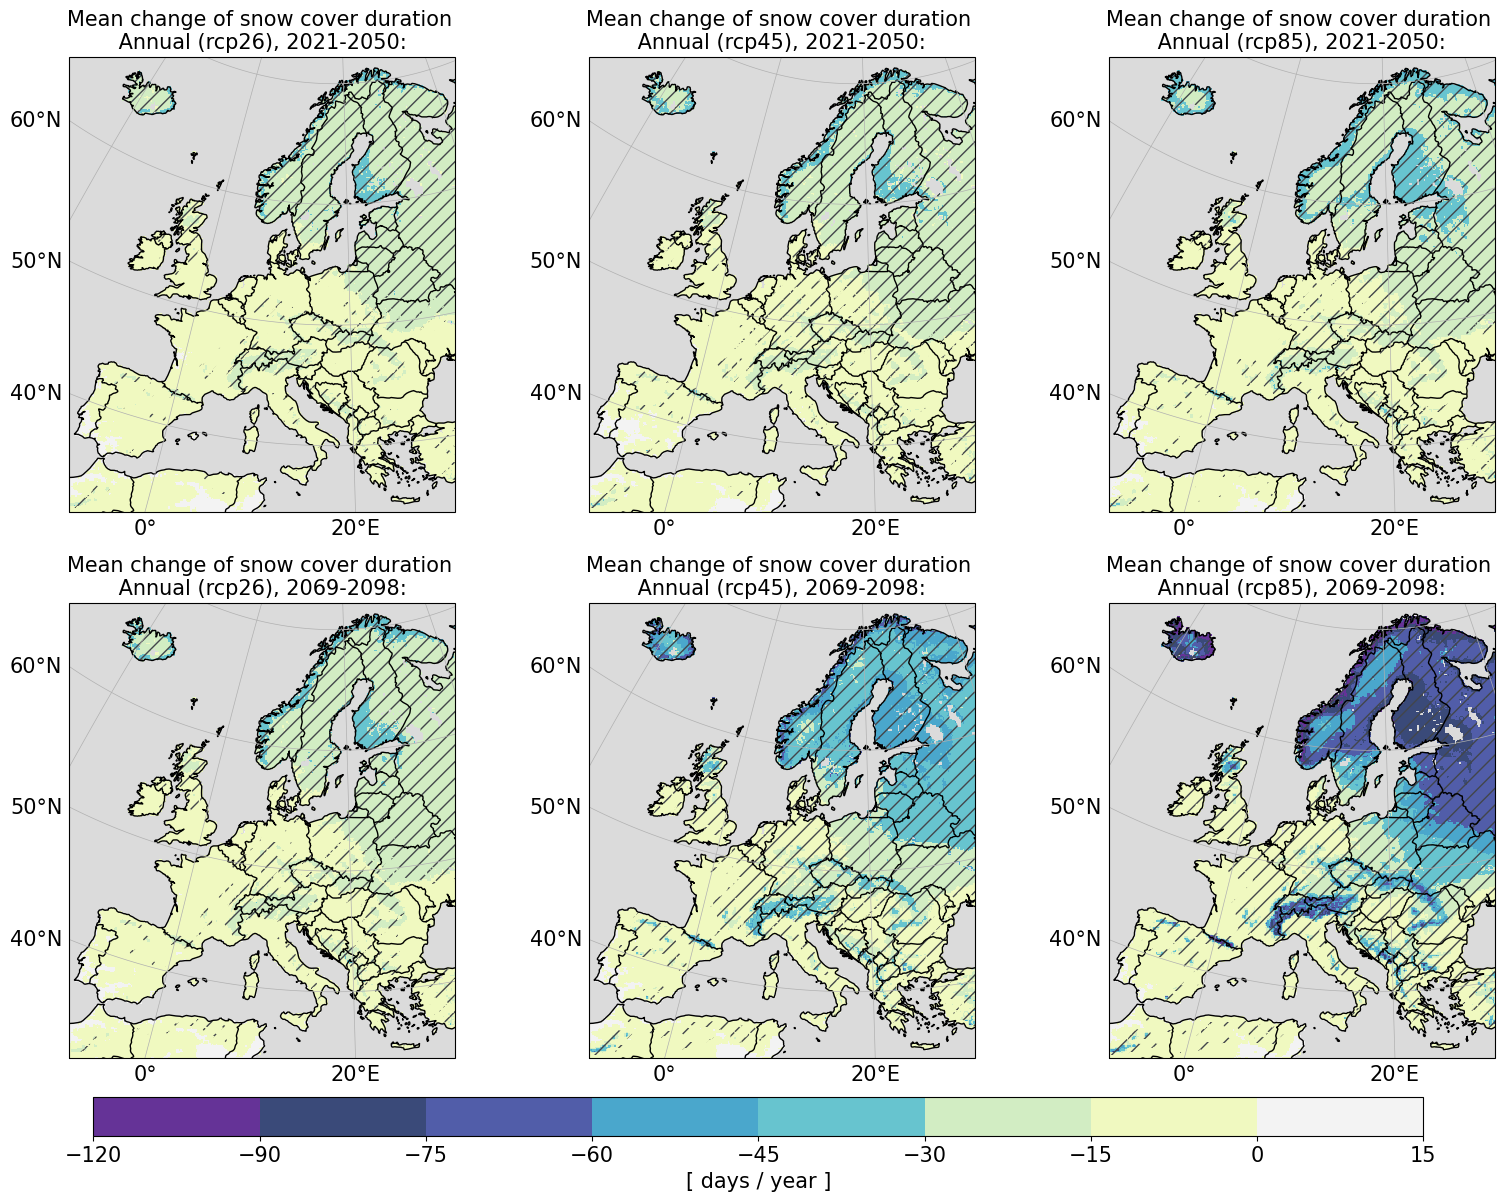

In [49]:
plot_6(
    ds_dict3,
    var="sd_ensemble_diff",
    mode="diff",
    robustness=True,
    hatchcolor="#43464B"
    )

In [60]:
file1='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_MEAN_1972_2001_rcp26.nc'
file2='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_MEAN_1972_2001_rcp45.nc'
file3='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_MEAN_1972_2001_rcp85.nc'
file4='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_MEAN_2022_2051_rcp26.nc'
file5='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_MEAN_2022_2051_rcp45.nc'
file6='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_MEAN_2022_2051_rcp85.nc'
file7='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_MEAN_2070_2099_rcp26.nc'
file8='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_MEAN_2070_2099_rcp45.nc'
file9='/work/ch0636/g300047/INDICES-SP-KB/Euro-Cordex-Indices/snow/snowday_timeseries/SNOWDAY-timeslice/ENS_MEAN_2070_2099_rcp85.nc'
ds1 = xr.open_mfdataset(file1, decode_times=False)
ds2 = xr.open_mfdataset(file2, decode_times=False)
ds3 = xr.open_mfdataset(file3, decode_times=False)
ds4 = xr.open_mfdataset(file4, decode_times=False)
ds5 = xr.open_mfdataset(file5, decode_times=False)
ds6 = xr.open_mfdataset(file6, decode_times=False)
ds7 = xr.open_mfdataset(file7, decode_times=False)
ds8 = xr.open_mfdataset(file8, decode_times=False)
ds9 = xr.open_mfdataset(file9, decode_times=False)
ds_dict2 = {
    "rcp26_1971-2000": ds1,
    "rcp45_1971-2000": ds2,
    "rcp85_1971-2000": ds3,
        }
ds_dict2["rcp26_2021-2050"] = ds4
ds_dict2["rcp45_2021-2050"] = ds5
ds_dict2["rcp85_2021-2050"] = ds6
ds_dict2["rcp26_2069-2098"] = ds7
ds_dict2["rcp45_2069-2098"] = ds8
ds_dict2["rcp85_2069-2098"] = ds9

/home/g/g300047/.conda/envs/mypy3/lib/python3.10/site-packages/cordex/core/domain.py:632: UserWarning: Order of vertices has changed since v0.3.2 to CF Conventions, see https://github.com/euro-cordex/py-cordex/issues/34
  warn(


<module 'matplotlib.pyplot' from '/home/g/g300047/.conda/envs/mypy3/lib/python3.10/site-packages/matplotlib/pyplot.py'>

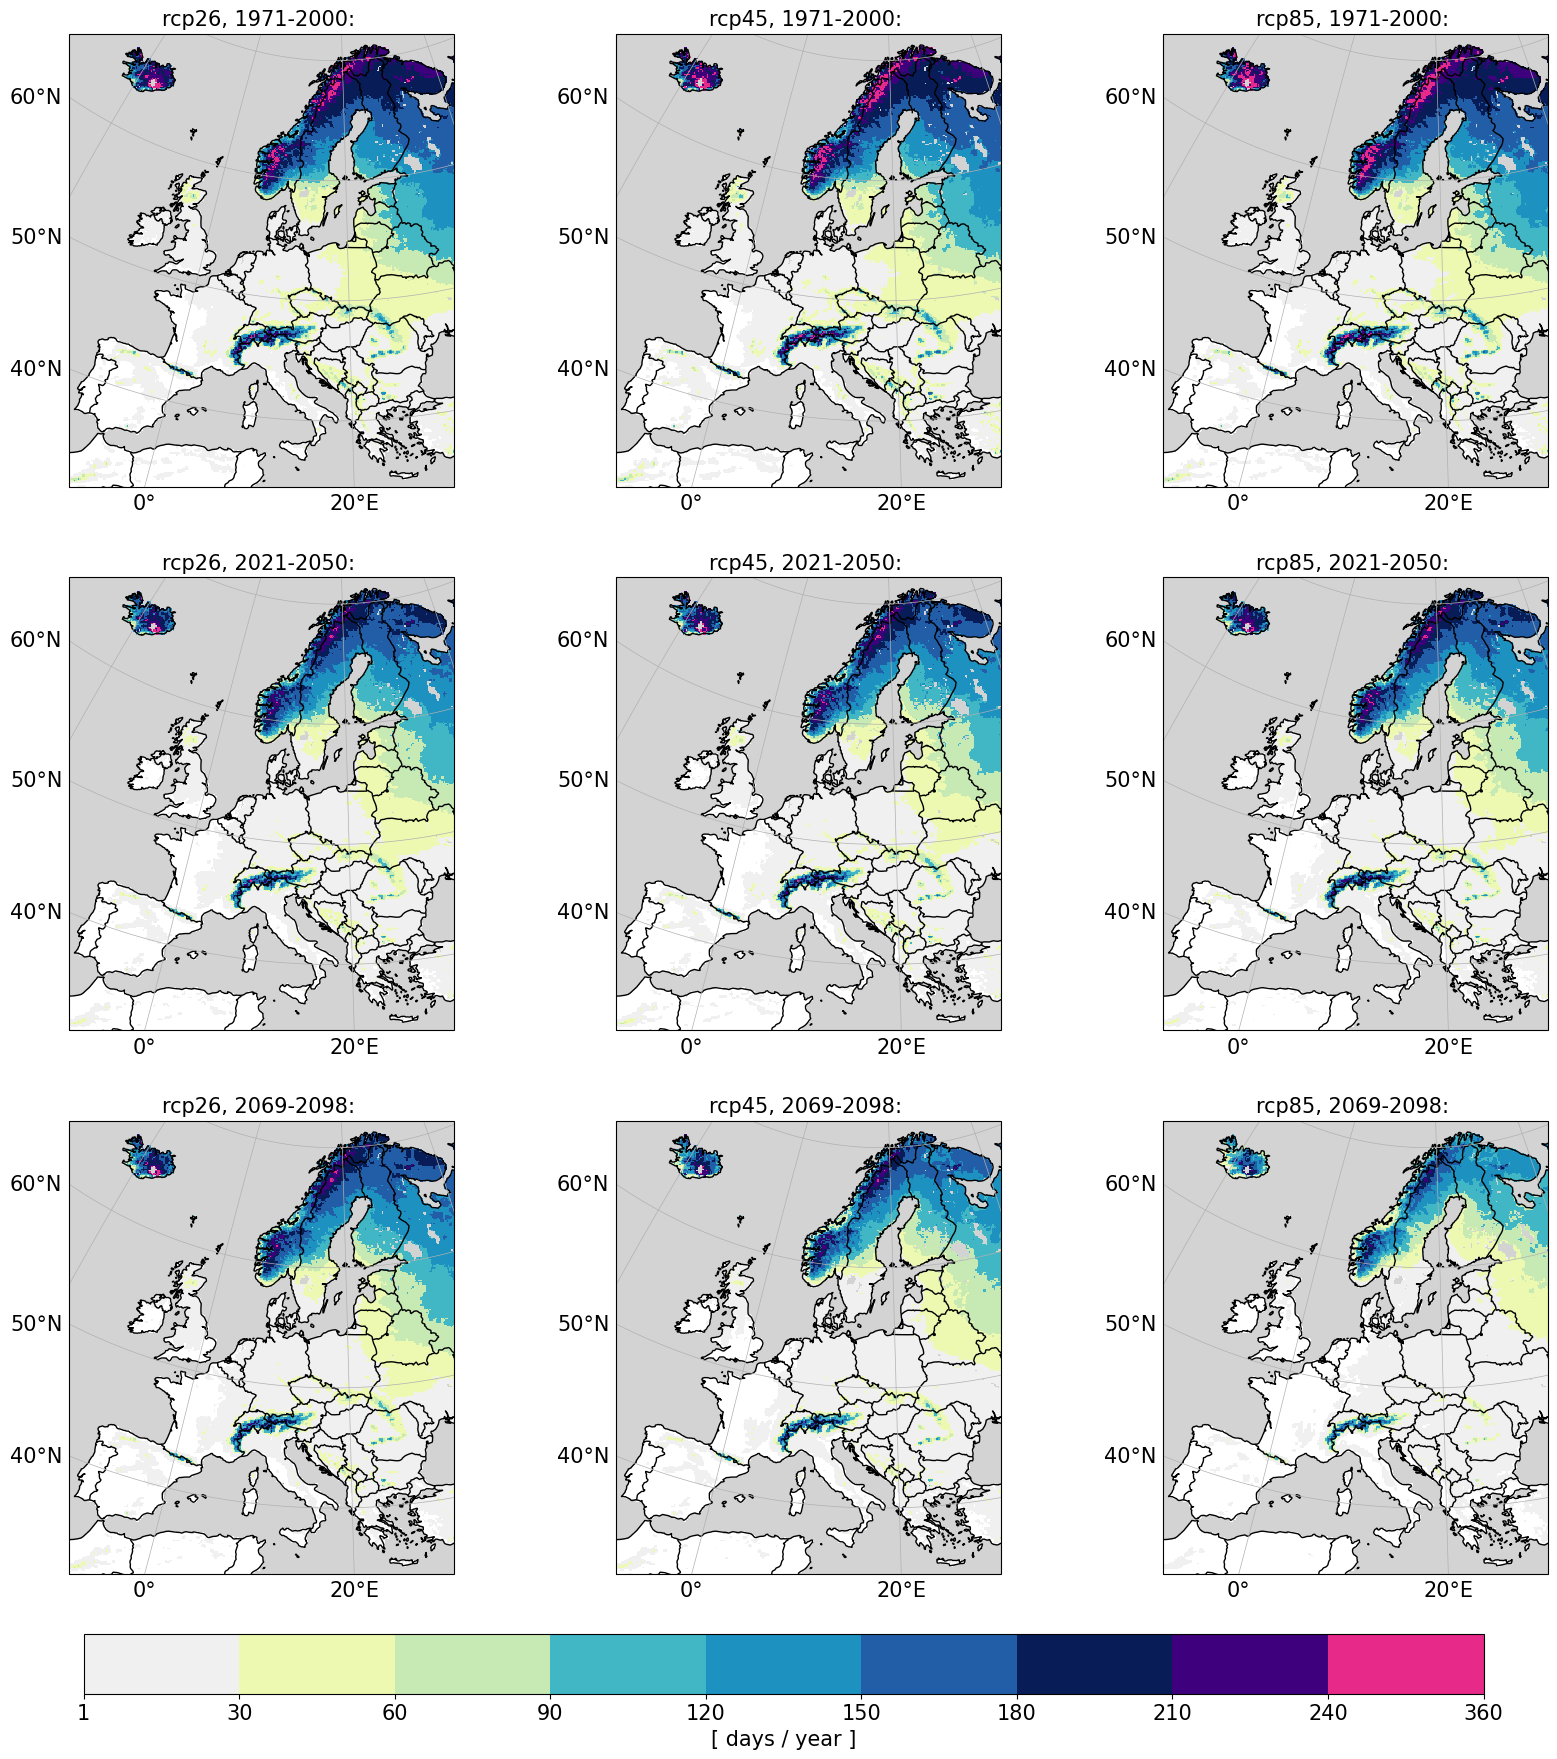

In [61]:
plot_9(
    ds_dict2,
    var="sd",
)

todo:
https://codebase.helmholtz.cloud/gerics/data-processing/calculate-thermal-comfort-indices-utci/-/blob/main/notebooks/utci-ensemble.ipynb
GitLabGitLab
Sign in · GitLab
Helmholtz Codebase - GitLab
10:30
calculate_ensemble_robustness
10:31
https://codebase.helmholtz.cloud/gerics/data-processing/calculate-thermal-comfort-indices-utci/-/blob/main/python/_statistics.py
GitLabGitLab
Sign in · GitLab
Helmholtz Codebase - GitLab
10:31
calculate_pvalue
10:32
check_significance